# Predicting NYC Housing Prices [Work in Progress]

**Current Status**: Actively optimizing spatial models and expanding feature engineering.  
**Latest Milestone**: Implemented Moran's I. 

## Goal of the Project
The goal of this project is to **predict housing prices in New York City** using a dataset that includes features such as property type, neighborhood, number of bedrooms, number of bathrooms, and area. By building a robust regression model, we aim to:

1. **Understand the key factors** that influence housing prices in NYC.
2. **Provide accurate price predictions** that can assist buyers, sellers, and real estate professionals in making informed decisions.
3. **Explore and visualize trends** in the housing market, such as the impact of location, property size, and type on pricing.

This project will involve:
- **Exploratory Data Analysis (EDA)** to uncover patterns and relationships in the data.
- **Feature Engineering** to create meaningful predictors from the raw data.
- **Model Development** using machine learning algorithms to predict housing prices.
- **Evaluation** of model performance using metrics like RMSE and R².

**Project Status**:
- ✅ Exploratory Data Analysis (Completed)  
- ✅ Baseline Model Development (Completed)  
- [ ] Spatial Feature Optimization (In Progress)
- [ ] K-fold Target Encoding (Planned)
- [ ] Model Selection and Optimization (Planned)

SECTION 1

# Load, clean and first look the data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

In [3]:
import geopandas as gpd

In [4]:
from sklearn.utils.parallel import Parallel, delayed

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

In [6]:
# Import dataset
file = '../data/NY-House-Dataset.csv'

In [7]:
# load the data
df = pd.read_csv(file)

In [8]:
# Inspect the data
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [9]:
# Check the dataset's structure
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print("\nColumn names and data types:")
print(df.info())

Number of rows: 4801, Number of columns: 17

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  ST

First Look Observations:
1. BROKERTITLE - Appears to just contain broker names (likely not useful for analysis)
2. BEDS (int) vs BATHS (float) - different data types
3. Address fields - Multiple address columns with potential redundancy:
   - ADDRESS, MAIN_ADDRESS, FORMATTED_ADDRESS all seem similar.
4. STATE - actually contains ZIP codes
5. Administrative geography fields - Inconsistent granularity:
   - ADMINISTRATIVE_AREA_LEVEL_2 mixes counties with country
   - STREET_NAME contains both street names and area names
   - SUBLOCALITY seems most promising for neighborhood analysis


- Consider creating 'NEIGHBORHOOD' and 'BOROUGH'/'COUNTY' feature
- Address fields could be helpfull if geocoding will be needed

In [10]:
# Inspect numerative features
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


Right-skewness evident from:

Price: Median 2,147,484,000<br>
Beds: Median 3 vs Max 50<br>
Bath: Median 2 vs Max 50<br>
Sqft: Median 2184.2 vs Max 65535.0<br>

Option 1: Apply log transformation<br>
Option 2: Analyze luxury segment separately<br>
Option 3: Winsorize extreme values<br>
<br>
Suspicious pattern detected in PROPERTYSQFT:

Exact same value (2184.21) appears as:
Mean, 50th percentile (median), 75th percentile<br>
This suggests: Missing values may have been imputed with this number

In [11]:
# Check for Nulls
df.isna().sum()

BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

No null data

In [12]:
# Check for duplicates
df.duplicated().sum()

np.int64(214)

In [13]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# Standartize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [16]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude'],
      dtype='object')

In [17]:
df.bath = df.bath.astype(int)

In [18]:
original_length = df.shape[0]

In [19]:
original_length

4587

## Exploratory Data Analysis (EDA)

## Price distribution analysis

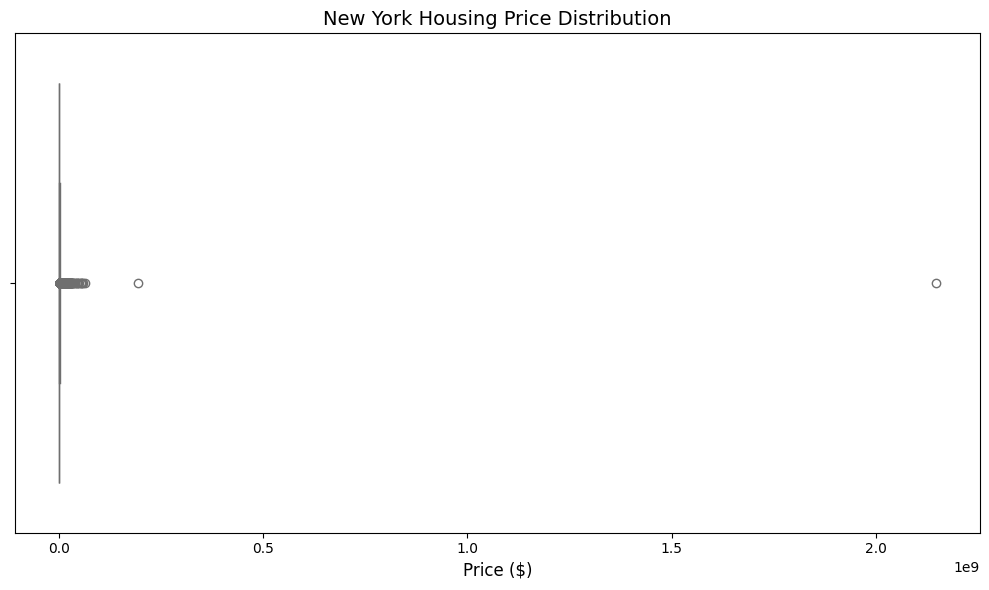

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [21]:
# Right-skewed price distribution. Should check for error data

In [22]:
df.sort_values(by=['price'], ascending=False).head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude
304,Brokered by ANNE LOPA REAL ESTATE,House for sale,2147483647,7,6,10000.000000,6659-6675 Amboy Rd,"New York, NY 10309","6659-6675 Amboy RdNew York, NY 10309",United States,New York,Richmond County,Staten Island,Amboy Road,"6659 Amboy Rd, Staten Island, NY 10309, USA",40.518484,-74.224418
1,Brokered by Serhant,Condo for sale,195000000,7,10,17545.000000,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
69,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,New York,New York County,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317
1075,Brokered by COMPASS,Co-op for sale,60000000,8,8,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,New York County,New York,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247
141,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,New York,New York County,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191


In [23]:
# 2147483647 is error input, should be dropped

In [24]:
df = df[df.price < df.price.max()]

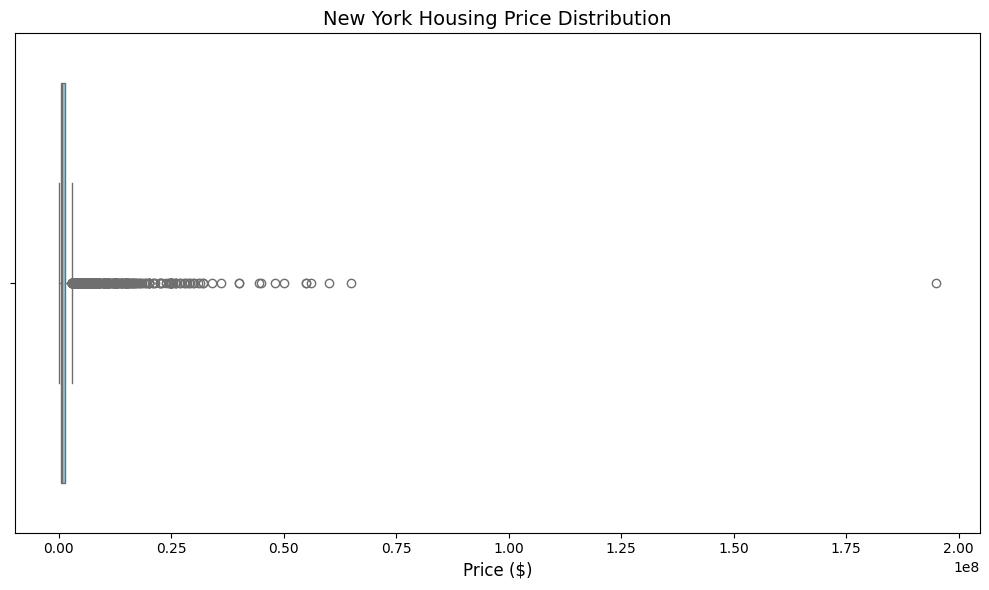

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [26]:
# Still have an outlier on 195000000$.I checked this property, apparently it is a very famous ultra expensive apartment.
# I will also exclude it

In [27]:
df = df[df.price < df.price.max()]

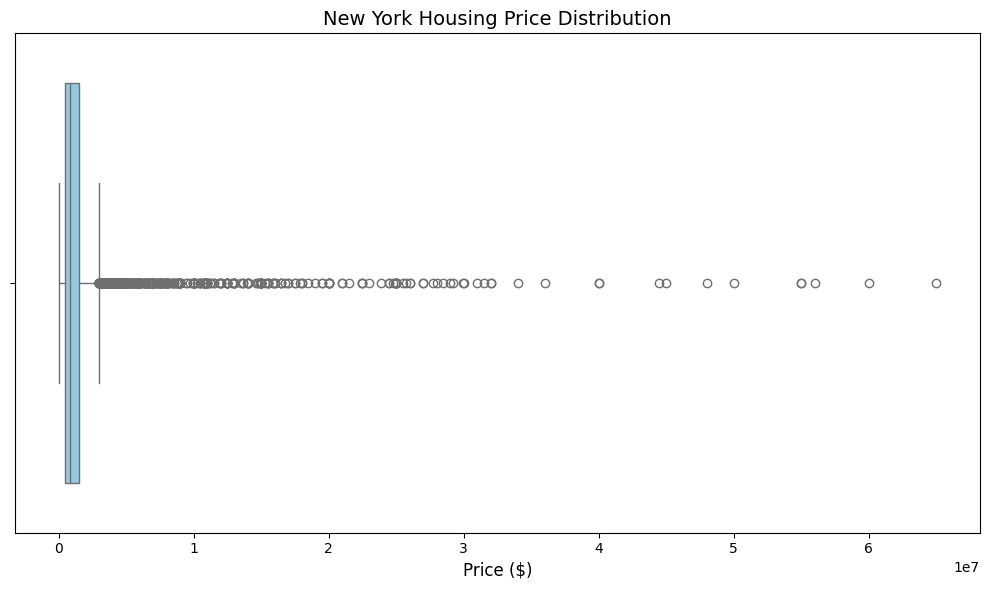

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [29]:
# Now boxplot looks reasonable

<Axes: xlabel='price', ylabel='type'>

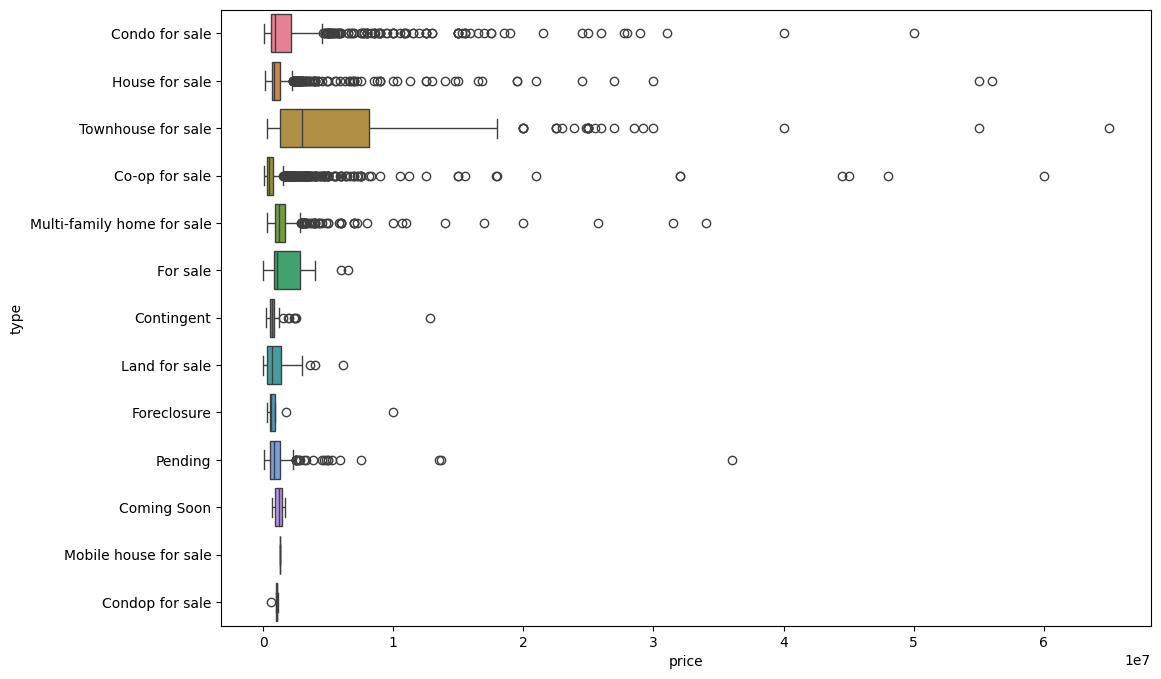

In [30]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='type', hue='type')

In [31]:
# Here we can see that we have a stratification of the market, apparently townhouses are considered more as luxurious property

In [32]:
# Calculate 90th percentile price thresholds by property type to identify price ceilings 
# for the top 10% of each property type and understand price distribution characteristics across categories

type_thresholds = df.groupby('type')['price'].quantile(0.9) 

In [33]:
print('0.90 quantile by type of houses')
print(type_thresholds.sort_values())
print('mean:',type_thresholds.mean())
print('median:',type_thresholds.median())

0.90 quantile by type of houses
type
Condop for sale                1111500.0
Contingent                     1119400.0
Mobile house for sale          1288000.0
Foreclosure                    1494900.0
Coming Soon                    1590400.0
Co-op for sale                 2150000.0
Pending                        2290400.0
House for sale                 2399600.0
Multi-family home for sale     2499000.0
Land for sale                  2729980.0
For sale                       4199900.0
Condo for sale                 5250000.0
Townhouse for sale            15892000.0
Name: price, dtype: float64
mean: 3385775.384615385
median: 2290400.0


In [34]:
# We again observe that the townhouse category is significantly different

In [35]:
# Calculate 50th percentile price thresholds by property type to assess entry - middle division point

type_thresholds_50 = df.groupby('type')['price'].quantile(0.5)
print('0.50 quantile by type of houses')
print(type_thresholds_50.sort_values())
print('mean:',type_thresholds_50.mean())
print('median:',type_thresholds_50.median())

0.50 quantile by type of houses
type
Co-op for sale                 425000.0
Foreclosure                    592450.0
Land for sale                  675000.0
Contingent                     689900.0
Pending                        825000.0
House for sale                 858000.0
Condo for sale                 880000.0
For sale                      1044500.0
Condop for sale               1072500.0
Coming Soon                   1172000.0
Multi-family home for sale    1199000.0
Mobile house for sale         1288000.0
Townhouse for sale            2995000.0
Name: price, dtype: float64
mean: 1055103.8461538462
median: 880000.0


In [36]:
# Threshold set at $3,000,000 based on central tendency analysis of the 0.90 quantile prices by property type
# And for entry - middle division set at $1,000,000
# Probable downside is that townhouses could be undervalued by modelling

# Also create cateforical price segment column for clear visual analysis (NOT SUITABLE FOR MODELLING)
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0, 1_000_000, 3_000_000, 12_000_000, np.inf],
    labels=['entry', 'mid', 'upper', 'luxury'],
    include_lowest=True,
    right=True
)

In [37]:
# Apply natural log transformation to price
df['log_price'] = np.log(df.price)

<Axes: xlabel='log_price', ylabel='type'>

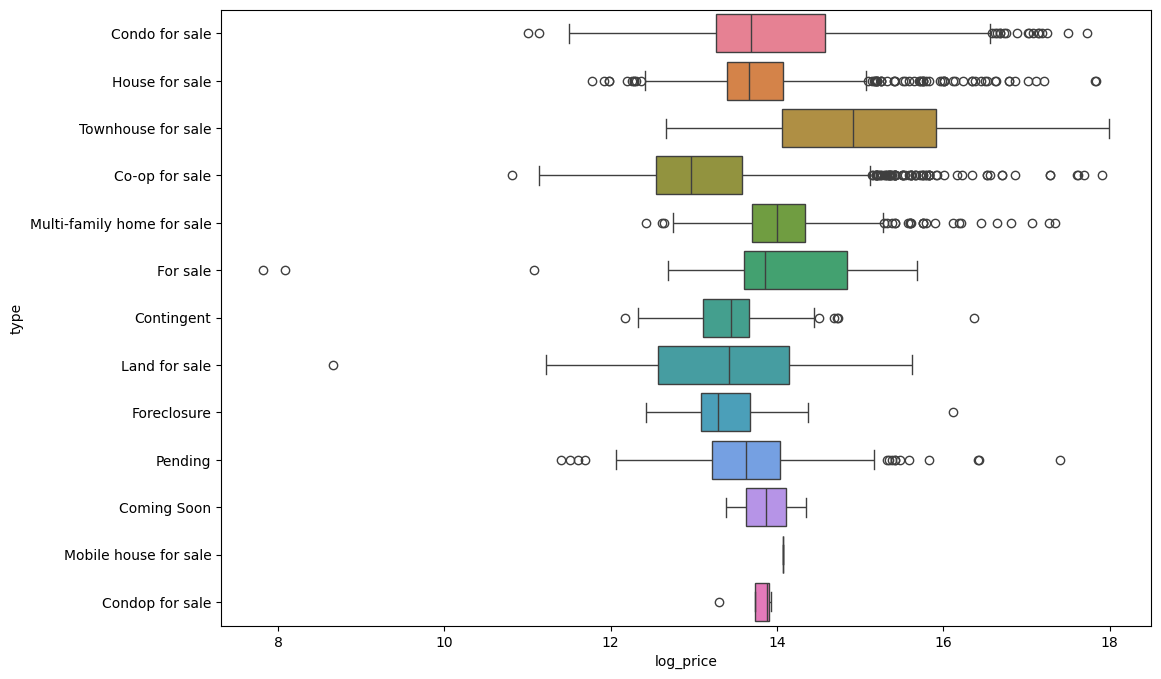

In [38]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='type', hue='type')

<Axes: xlabel='log_price', ylabel='Count'>

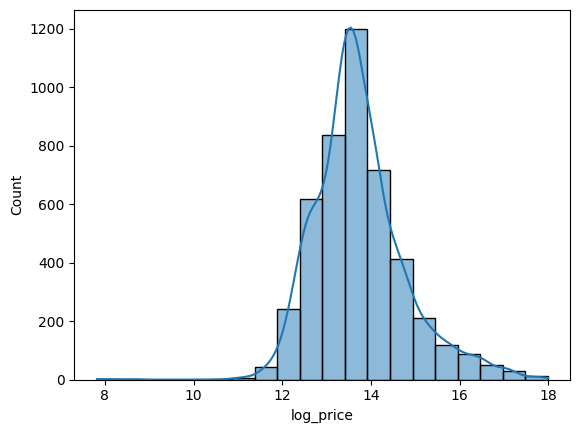

In [39]:
sns.histplot(df.log_price, bins=20, kde=True)

In [40]:
# log_price looks quite normal

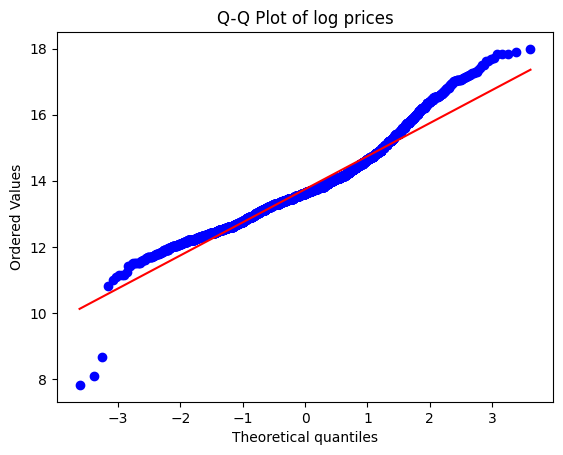

In [41]:
# Identify outliers on Q-Q plot
probplot(df['log_price'], dist="norm", plot=plt)
plt.title("Q-Q Plot of log prices")
plt.show()

In [42]:
# I see three outliers in lower range

In [43]:
df.sort_values('price').head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude,price_segment,log_price
317,Brokered by Living NY - Main Office,For sale,2494,2,1,2184.207862,635 W 170th St Apt 4F,"New York, NY 10032","635 W 170th St Apt 4FNew York, NY 10032",New York,New York County,New York,Manhattan,635,"635 W 170th St #4f, New York, NY 10032, USA",40.843406,-73.940795,entry,7.821643
310,Brokered by Living NY - Main Office,For sale,3225,3,1,2184.207862,635 W 170th St Apt 2C,"New York, NY 10032","635 W 170th St Apt 2CNew York, NY 10032",New York,New York County,New York,Manhattan,635,"635 W 170th St #2c, New York, NY 10032, USA",40.843406,-73.940795,entry,8.078688
360,Brokered by Century 21 Realty First,Land for sale,5800,3,2,2184.207862,4515 Avenue N Lot 5,"Brooklyn, NY 11234","4515 Avenue N Lot 5Brooklyn, NY 11234",New York,Kings County,Brooklyn,Flatlands,4515,"4515 Avenue N #5, Brooklyn, NY 11234, USA",40.618915,-73.931211,entry,8.665613
463,Brokered by Morris Park Realty Group,Co-op for sale,49500,3,2,800.000000,150 City Island Ave Unit E3,"Bronx, NY 10464","150 City Island Ave Unit E3Bronx, NY 10464",New York,Bronx County,The Bronx,City Island,150,"150 City Island Ave #3e, Bronx, NY 10464, USA",40.843284,-73.784603,entry,10.809728
979,Brokered by COMPASS,Condo for sale,60000,3,1,445.000000,2 E 55th St Unit 809W35,"Manhattan, NY 10022","2 E 55th St Unit 809W35Manhattan, NY 10022",New York,New York County,New York,Manhattan,2,"2 E 55th St 809 35, New York, NY 10022, USA",40.761398,-73.974613,entry,11.002100


In [44]:
# Data cleaning:
# - $2,494 and $3,225 (Manhattan apartments) - Below realistic thresholds
# - $5,800 (land) - Far below NYC market minimums

df = df[df.price>10000]

In [45]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [46]:
1 - len(df)/original_length

0.0010900370612600963

In [47]:
# dropped only 0.1% of data

## Other variables distribution

In [48]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude', 'price_segment',
       'log_price'],
      dtype='object')

### _Brokertitle_

In [49]:
df.brokertitle.value_counts()

brokertitle
Brokered by COMPASS                              435
Brokered by Douglas Elliman - 575 Madison Ave    109
Brokered by Brown Harris Stevens                  93
Brokered by Corcoran East Side                    86
Brokered by RE MAX Edge                           75
                                                ... 
Brokered by Tworealestate Llc                      1
Brokered by Blue Key Real Estate Brokerage         1
Brokered by Douglas Elliman - New Hyde Park        1
Brokered by Renken Realty LLC                      1
Brokered by Contact Realty Ii Corp                 1
Name: count, Length: 1035, dtype: int64

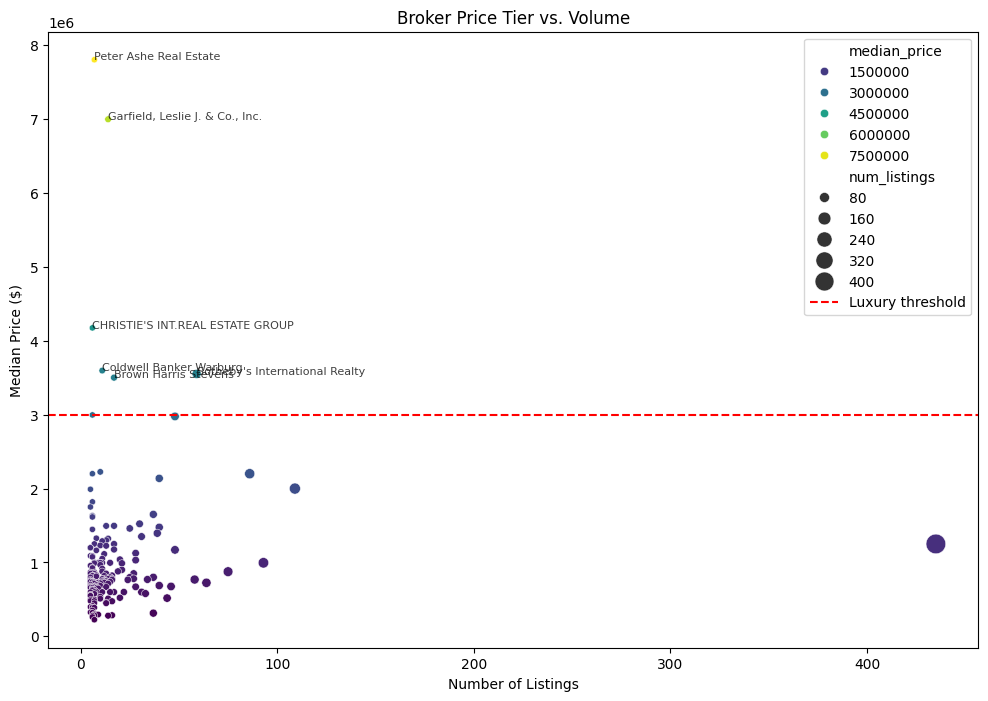

In [50]:
# Get broker stats: count and median price
broker_stats = df.groupby('brokertitle').agg(
    num_listings=('price', 'count'),
    median_price=('price', 'median'),
    max_price=('price', 'max')
).sort_values('median_price', ascending=False)

# Filter brokers with ≥5 listings (avoid noise)
broker_stats = broker_stats[broker_stats['num_listings'] >= 5]

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=broker_stats,
    x='num_listings',
    y='median_price',
    hue='median_price',
    palette='viridis',
    size='num_listings',
    sizes=(20, 200)
)

# Annotate top luxury brokers
top_luxury = broker_stats[broker_stats['median_price'] > 3_000_000]  # Adjust thresholdb
for idx, row in top_luxury.iterrows():
    plt.annotate(
        idx.replace('Brokered by ', '').split('-')[0].strip(),
        (row['num_listings'], row['median_price']),
        fontsize=8, alpha=0.75
    )

#plt.xscale('log')  # Better visibility for wide-ranging counts
plt.xlabel('Number of Listings')
plt.ylabel('Median Price ($)')
plt.title('Broker Price Tier vs. Volume')
plt.axhline(y=3_000_000, color='red', linestyle='--', label='Luxury threshold') 
plt.legend()
plt.show()

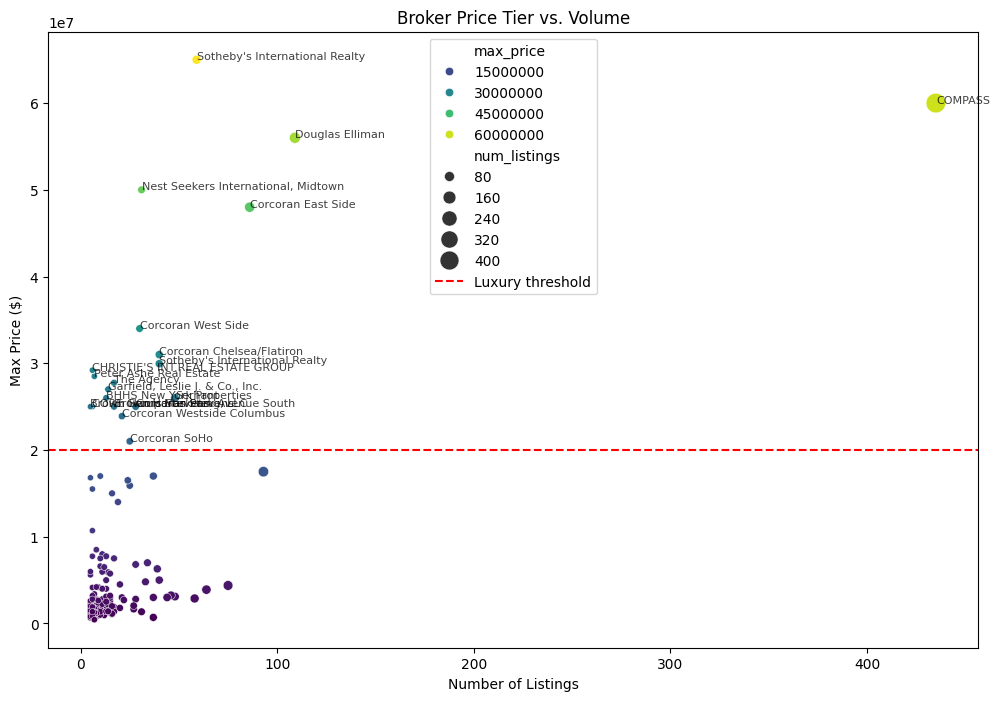

In [51]:
# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=broker_stats,
    x='num_listings',
    y='max_price',
    hue='max_price',
    palette='viridis',
    size='num_listings',
    sizes=(20, 200)
)

# Annotate top luxury brokers
top_luxury = broker_stats[broker_stats['max_price'] > 20_000_000]  # Adjust thresholdb
for idx, row in top_luxury.iterrows():
    plt.annotate(
        idx.replace('Brokered by ', '').split('-')[0].strip(),
        (row['num_listings'], row['max_price']),
        fontsize=8, alpha=0.75
    )

#plt.xscale('log')  # Better visibility for wide-ranging counts
plt.xlabel('Number of Listings')
plt.ylabel('Max Price ($)')
plt.title('Broker Price Tier vs. Volume')
plt.axhline(y=20_000_000, color='red', linestyle='--', label='Luxury threshold') 
plt.legend()
plt.show()

In [52]:
broker_stats.head(10)

,num_listings,median_price,max_price
brokertitle,,,
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,7,7800000.0,28500000
"Brokered by Garfield, Leslie J. & Co., Inc.",14,6995000.0,27000000
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,6,4172500.0,29200000
Brokered by Coldwell Banker Warburg,11,3595000.0,7995000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
Brokered by Brown Harris Stevens - 1926 Broadway,17,3500000.0,25000000
"Brokered by CORE Group Marketing, LLC",6,2994999.5,25000000
Brokered by Serhant,48,2974999.5,26000000
Brokered by R New York,10,2225000.0,16995000


In [53]:
broker_stats.sort_values(by='num_listings', ascending=False).head(10)

,num_listings,median_price,max_price
brokertitle,,,
Brokered by COMPASS,435,1250000.0,60000000
Brokered by Douglas Elliman - 575 Madison Ave,109,1999000.0,56000000
Brokered by Brown Harris Stevens,93,995000.0,17500000
Brokered by Corcoran East Side,86,2200000.0,48000000
Brokered by RE MAX Edge,75,875000.0,4380000
Brokered by Winzone Realty Inc,64,724500.0,3900000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
Brokered by E Realty International Corp,58,768500.0,2880000
Brokered by Serhant,48,2974999.5,26000000


In [54]:
df.sort_values(by='price', ascending=False).head(15)

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude,price_segment,log_price
68,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,New York,New York County,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317,luxury,17.989898
1039,Brokered by COMPASS,Co-op for sale,60000000,8,8,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,New York County,New York,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247,luxury,17.909855
137,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,New York,New York County,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191,luxury,17.840862
3,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2,14175.000000,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856,luxury,17.822844
97,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,55000000,8,8,12000.000000,25 Riverside Dr,"New York, NY 10023","25 Riverside DrNew York, NY 10023",United States,New York,New York County,New York,Riverside Drive,"25 Riverside Dr, New York, NY 10023, USA",40.782238,-73.984632,luxury,17.822844
602,"Brokered by Nest Seekers International, Midtown",Condo for sale,50000000,6,6,6569.000000,100 Vandam St Apt 20A,"New York, NY 10013","100 Vandam St Apt 20ANew York, NY 10013",New York,New York County,New York,Manhattan,100,"100 Vandam St #20a, New York, NY 10013, USA",40.726633,-74.008832,luxury,17.727534
1401,Brokered by Corcoran East Side,Co-op for sale,48000000,5,2,2184.207862,740 Park Ave # 4 & 5B,"New York, NY 10021","740 Park Ave # 4 & 5BNew York, NY 10021",New York,New York County,New York,Manhattan,740,"740 Park Ave #5, New York, NY 10021, USA",40.770752,-73.964528,luxury,17.686712
3255,Brokered by Sotheby's International Realty - E...,Co-op for sale,45000000,5,2,2184.207862,4 E 66th St Fl 7,"New York, NY 10065","4 E 66th St Fl 7New York, NY 10065",New York,New York County,New York,Manhattan,4,"4 E 66th St Fl 7, New York, NY 10065, USA",40.768301,-73.969734,luxury,17.622173
3427,Brokered by Sotheby's International Realty - E...,Co-op for sale,44500000,5,6,2184.207862,2 E 67th St Fl 9,"New York, NY 10065","2 E 67th St Fl 9New York, NY 10065",New York,New York County,New York,Manhattan,2,"2 E 67th St Fl 9, New York, NY 10065, USA",40.768973,-73.969136,luxury,17.611000
1413,Brokered by Douglas Elliman - New Development,Condo for sale,40000000,5,6,7488.000000,111 Murray St Ph 2,"New York, NY 10007","111 Murray St Ph 2New York, NY 10007",New York,New York County,New York,Manhattan,111,"111 Murray St Ph 2, New York, NY 10007, USA",40.715351,-74.012844,luxury,17.504390


In [55]:
selected_brokers = [
    'COMPASS',
    'Sotheby\'s International Realty - East Side Manhattan Brokerage',
    'Peter Ashe Real Estate- Peter Ashe Real Estate',
    'Douglas Elliman - 575 Madison Ave',
    'Corcoran East Side',
    'Serhant',
    'Garfield, Leslie J. & Co., Inc.',
    "CHRISTIE'S INT.REAL ESTATE GROUP",
    'Coldwell Banker Warburg',
]

# Filter data
plot_data = df[df['brokertitle'].str.contains('|'.join(selected_brokers))]

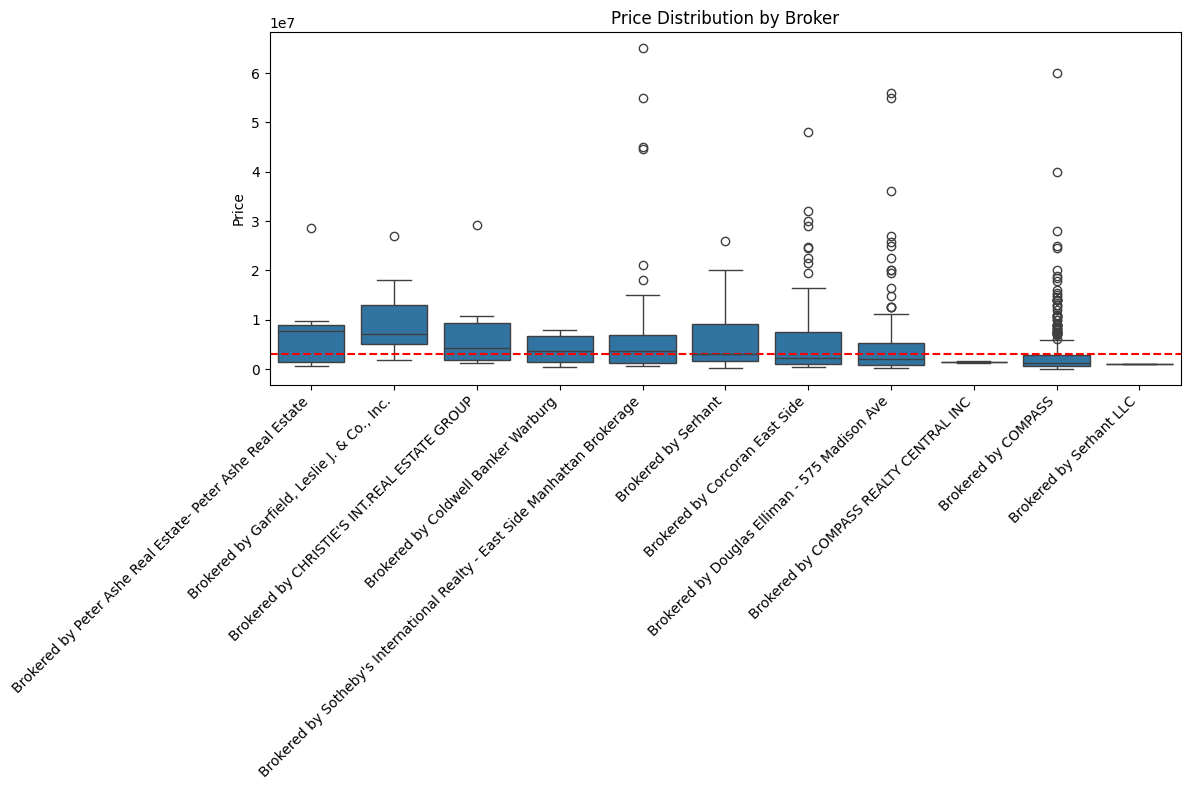

In [56]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=plot_data,
    x='brokertitle',
    y='price',
    order=plot_data.groupby('brokertitle')['price'].median().sort_values(ascending=False).index,
    showfliers=True  # Hide outliers initially
)

# Add context
plt.axhline(y=3_000_000, color='red', linestyle='--', label='Luxury threshold')
plt.xticks(rotation=45, ha='right')
#plt.yscale('log')  # Critical for NYC price ranges
plt.title('Price Distribution by Broker')
plt.ylabel('Price')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [57]:
broker_stats

,num_listings,median_price,max_price
brokertitle,,,
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,7,7800000.0,28500000
"Brokered by Garfield, Leslie J. & Co., Inc.",14,6995000.0,27000000
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,6,4172500.0,29200000
Brokered by Coldwell Banker Warburg,11,3595000.0,7995000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
...,...,...,...
Brokered by RE/MAX City Square,7,284888.0,1268000
Brokered by Keller Williams Realty Liberty,14,279250.0,1399000
Brokered by Goldstone N Y Realty Llc,6,278500.0,880000


In [58]:
# Add new features based on brokertitle column (See Feature Engineering section)

### _Type_

In [ ]:
df.type.value_counts()

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='type', hue='type')

In [ ]:
# Identify types to potentially consolidate
rare_types = df['type'].value_counts()[df['type'].value_counts() < 20].index
print(f"Rare types (<20 listings): {list(rare_types)}")

In [ ]:
# Group rare types in other category
df['type_clean'] = np.where(df['type'].isin(rare_types), 'Other', df['type'])

In [ ]:
# Averages by type
df.groupby('type_clean')[['price', 'beds', 'bath', 'propertysqft', ]].mean().sort_values('price', ascending=False)

In [ ]:
# Here we also can see that townhouse type differs from others

In [ ]:
# Calculate market share by types
market_share = (df.groupby('type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='type_clean',
            hue='type_clean')

In [ ]:
market_share

In [ ]:
# Additionally consolidate rare property types (<1% market share) into 'Other' category
df['type_clean'] = np.where(df['type_clean'].isin(market_share[market_share < 1.0].index),'Other', df['type_clean'])

In [ ]:
# Calculate market share by types
market_share = (df.groupby('type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='type_clean',
            hue='type_clean')

In [ ]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='type_clean', hue='type_clean')

### _Beds_

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='beds', hue='beds')

In [ ]:
# Here we also have a skewed distribution

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=True,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [ ]:
# Market doesn't following beds after 10-12 bedrooms. Most high priced properties have 1-8 bedrooms. So it's probably a good idea divide those groups

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=False,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [ ]:
# Here we also see linear relation beds - price up to 10 bedrooms

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='beds', y='price', hue='price_segment')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='beds', y='price', hue='type_clean')

plt.tight_layout()

In [ ]:
# Those properties with high bedroom number are mostly multi-family homes

In [ ]:
sns.scatterplot(data=df, x='beds', y='bath', hue='price_segment')

In [ ]:
# ok, so no luxurios entries in high number bedroom segment

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='beds', hue='beds')

In [ ]:
df['beds'].quantile(0.99)

In [ ]:
# So 12 bedrooms seems as a good threshold. Feature will be added in Feature Engineering section

In [ ]:
# Calculate market share by bedrooms
market_share = (df.groupby('beds')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

In [ ]:
# Mean price dinamic based on number of bedrooms
market_share = (df.groupby('beds')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

In [ ]:
# The 1-6 bedroom homes aren’t the most expensive, but they dominate the market – they make up nearly 90% of listings.

In [ ]:
df['log_beds'] = np.log1p(df['beds'])

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df.log_beds)

In [ ]:
df['beds_sqrt'] = np.sqrt(df['beds'])

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df.beds_sqrt)

In [ ]:
df['beds_asinh'] = np.arcsinh(df['beds'])

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df.beds_asinh)

In [ ]:
bins = [0, 1, 2, 3, 4, 5, 6, 10, 20, 50]
labels = ['1', '2', '3', '4', '5', '6', '7-10', '11-20', '20+']
df['beds_binned'] = pd.cut(df['beds'], bins=bins, labels=labels)

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df.beds_binned)

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='beds_binned', y='price', data=df, order=labels, hue='type_clean')

### Bath

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='bath', hue='bath')

In [ ]:
df.bath.describe()

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='bath',
    y='price',
    showfliers=True,
    hue='bath'
)
#plt.yscale('log')
plt.title('Price Distribution by Bathroom Count', fontweight='bold')

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(df,y='bath', hue='type')

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='bath', y='log_price', hue='type_clean')

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='price', hue='type_clean', showfliers=False)

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='log_price', hue='type_clean', showfliers=False)

In [ ]:
# Mean price dinamic based on number of bathrooms
market_share = (df.groupby('bath')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='bath',
            hue='bath',
            palette='Blues_d')

In [ ]:
df['log_bath'] = np.log1p(df.bath)

In [ ]:
plt.figure(figsize=(12, 8))
sns.histplot(df.log_bath)

### *Propertysqft*

In [ ]:
sns.histplot(df.propertysqft)

In [ ]:
df.propertysqft.value_counts()

In [ ]:
df.propertysqft.describe()

In [ ]:
# The value 2184.207862 appears to have been used as a substitute for missing values.

In [ ]:
df[df.propertysqft!=2184.207862].propertysqft.describe()

In [ ]:
# On the dataset without 2184.207862, the median is 1495.50. I’ll impute missing values with this median and mark them with the area_missing flag.

In [ ]:
df['area_missing'] = np.where(df['propertysqft'] == 2184.207862, 1, 0)

In [ ]:
df['area_missing'].value_counts()

In [ ]:
df['propertysqft'] = np.where(df['area_missing'] == 1, 1495.512345, df['propertysqft'])

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, y='type_clean', x='price', hue='area_missing')

In [ ]:
# Do not see here significal disproportions

In [ ]:
df.propertysqft.describe()

In [ ]:
sns.boxplot(df.propertysqft)

In [ ]:
sns.histplot(df.propertysqft, bins=10)

In [ ]:
df['propertysqft'].quantile(0.995)

In [ ]:
# Propertysqft data looks highly skewed. I'll apply log transform to compensate

In [ ]:
df['log_area'] = np.log1p(df.propertysqft)

In [ ]:
sns.histplot(df.log_area, bins=10)

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='log_area', y='log_price', hue='type_clean')

In [ ]:
# In this graph, we can observe data clustering. The vertical line of dots corresponds to the substituted value that was used 
# to fill in missing entries. The most expensive properties across all area ranges are condos.

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df[df.area_missing==True], y='type_clean', hue='type_clean')

In [ ]:
# Mean price dinamic based on type
market_share = (df.groupby('type_clean')['price'].sum()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='type_clean',
            hue='type_clean')

In [ ]:
# Mean price dinamic based on type
market_share = (df.groupby('type_clean')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='type_clean',
            hue='type_clean')

In [ ]:
# Most properites with missed values are co-op, and that item has the least mean price. So those missing properties shouldn't
# distort upper market.

### All address data

In [ ]:
address_columns = ['address', 'state',
       'main_address', 'administrative_area_level_2', 'locality',
       'sublocality', 'street_name', 'long_name', 'formatted_address']

In [ ]:
df[address_columns].head(7)

In [ ]:
# Address and formatted address probably should be dropped.

In [ ]:
# State contain zip. Could be usefull

In [ ]:
df['zip'] = df['state'].str[-5:]

# Filter invalid ZIPs (e.g., non-numeric)
df['zip'] = df['zip'].where(df['zip'].str.isdigit())

In [ ]:
df.zip.isna().sum()

In [ ]:
df.zip.value_counts()

In [ ]:
df.state.value_counts()

In [ ]:
df.administrative_area_level_2.value_counts()

In [ ]:
# Messy feature, better should use borough

In [ ]:
#locality	sublocality	street_name	long_name

In [ ]:
df.locality.value_counts()

In [ ]:
df.sublocality.value_counts()

In [ ]:
df.street_name.value_counts()

In [ ]:
df.long_name.value_counts()

In [ ]:
address_columns_to_drop = ['address',
 'state',
 'main_address',
 'administrative_area_level_2',
 'locality',
 'sublocality',
 'street_name',
 'long_name']

In [ ]:
df = df.drop(columns=address_columns_to_drop)

In [ ]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [ ]:
df.columns

### Add boroughs

In [ ]:
boroughs_file = '../data/nyc_boroughs.geojson'

In [ ]:
gdf_boroughs = gpd.read_file(boroughs_file)

In [ ]:
gdf_boroughs.plot()

In [ ]:
gdf_boroughs

In [ ]:
gdf_boroughs_utm = gdf_boroughs.to_crs("EPSG:32618")

In [ ]:
gdf_houses = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs=gdf_boroughs.crs
)

In [ ]:
df_with_borough = gpd.sjoin(
    gdf_houses,
    gdf_boroughs[['name', 'geometry']],  # Only keep needed columns
    how='left',
    predicate='within'
)

In [ ]:
df_with_borough

In [ ]:
df['borough'] = df_with_borough['name']

In [ ]:
df['borough'].isna().sum()

In [ ]:
# Nothing missing

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="borough", data=df)

In [ ]:
# Looks great!

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='borough', hue='borough')

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='borough', hue='borough')

In [ ]:
df.columns

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='beds', y='borough', hue='borough')

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='beds_binned', y='price', data=df, order=labels, hue='borough')

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='bath', y='borough', hue='borough')

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='borough', hue='price_segment')

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='borough', y='price', hue='type_clean', showfliers=False)

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='borough', hue='borough')

In [ ]:
# Calculate market share by types
market_share = (df.groupby('borough')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='borough',
           hue='borough')

In [ ]:
# Ok, those plots confirm what we already know, all the money is in Manhattan.

In [ ]:
df.borough.value_counts()

In [ ]:
# Enconding for boroughs. Only top boroughs
borough_dummies = pd.get_dummies(df['borough'], prefix='borough')

top_boroughs = ['borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']
df = pd.concat([df, borough_dummies[top_boroughs]], axis=1)

In [ ]:
df.columns

In [ ]:
print(np.log(60_000_000))
print(np.log(30_000_000))
print(np.log(10_000_000))
print(np.log(2_000_000))
print(np.log(1_000_000))
print(np.log(500_000))

In [ ]:
### Add price_per_sqft

In [ ]:
df['price_per_sqft'] = df.price/df.propertysqft

In [ ]:
df['log_pps'] = np.log1p(df.price_per_sqft)

In [ ]:
sns.histplot(df, x='price_per_sqft')

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='type_clean', hue='type_clean')

In [ ]:
df[['price_per_sqft', 'price']].corr()

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='borough')

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='type_clean')

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='price_segment')

## Correlation

In [ ]:
df.columns

In [ ]:
numerical_columns = ['price', 'beds', 'bath', 'propertysqft',
       'log_price','log_beds', 'log_bath',
       'log_area','price_per_sqft']

In [ ]:
corr = df[numerical_columns].corr()

In [ ]:
sns.heatmap(corr)

In [ ]:
sns.pairplot(df[numerical_columns])

SECTION 2

## Exploratory Sparial Data Analysis (ESDA)

## Spatial distribution

In [ ]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)

In [ ]:
gdf_utm = gdf.to_crs("EPSG:32618")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df, palette="Spectral")

In [ ]:
gdf_utm.plot(column="log_price", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("NYC Housing Prices (log scale)")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df[df.type=='Townhouse for sale'], palette="Spectral")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_area", data=df, palette="Spectral")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="type_clean", data=df)

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="price_segment", data=df)

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_pps", data=df, palette="Spectral")

## Spatial distribution

In [ ]:
# Extract UTM coordinates for spatial analysis
gdf_utm['x_utm'] = gdf_utm.geometry.x
gdf_utm['y_utm'] = gdf_utm.geometry.y

In [ ]:
from libpysal.weights import DistanceBand
from esda.moran import Moran

# Spatial weights using UTM coordinates
coords = gdf_utm[['x_utm', 'y_utm']].values
w = DistanceBand.from_array(coords, threshold=1000)  # 1km threshold
moran = Moran(gdf_utm['price'], w)

In [ ]:
print(f"Moran’s I: {moran.I:.3f}, p-value: {moran.p_sim:.3f}")

# Expected Moran’s I under randomness: E[I] = -1/(n-1)
print(f"Expected I under randomness: {-1/(len(gdf_utm)-1):.3f}")

In [ ]:
gdf_manhattan = gdf_utm[gdf_utm['borough'] == 'Manhattan']
coords_manh = gdf_manhattan[['x_utm', 'y_utm']].values
w_manh = DistanceBand.from_array(coords_manh, threshold=1000)  # 1km threshold
moran_manh = Moran(gdf_manhattan['price'], w_manh)

In [ ]:
print(f"Moran’s I: {moran_manh.I:.3f}, p-value: {moran_manh.p_sim:.3f}")

# Expected Moran’s I under randomness: E[I] = -1/(n-1)
print(f"Expected I under randomness: {-1/(len(gdf_manhattan)-1):.3f}")

# **🔽🔽🔽 SECTION UNDER CONSTRUCTION 🔽🔽🔽**
## ⚠️ PROCEED WITH CAUTION

In [ ]:
from esda import G_Local

In [ ]:
w_G = DistanceBand.from_array(coords, threshold=750)

In [ ]:

z_value = 1.96

# Calculate hotspots (reuse the same weights `w` from Moran’s I)
gi = G_Local(gdf_utm['price'], w_G)
gdf_utm['is_hotspot'] = (gi.Zs > z_value).astype(int)

In [ ]:
sum(gi.Zs>z_value)

In [ ]:
# Visualize
plt.figure(figsize=(12, 8))
ax = gdf_boroughs_utm.plot(figsize=(10,10), color='none', edgecolor='gainsboro', zorder=3)
gdf_utm.plot(column='is_hotspot', 
             cmap='coolwarm', 
             legend=True,
            markersize=2,
            ax=ax)
plt.title(f"G local with Z={z_value}")

In [ ]:
import folium
from folium import Marker, Circle

map = folium.Map(location=[40.75,-73.8], tiles='openstreetmap', zoom_start=11)
#for idx, row in gdf_utm[gdf_utm.is_hotspot==1].iterrows():
 #   Marker([row['latitude'], row['longitude']]).add_to(map)

def color_producer(val):
    if val == 1:
        return 'red'
    else:
        return 'grey'
    
for i in range(0,len(gdf_utm)):
    Circle(
        location= [gdf_utm.iloc[i]['latitude'], gdf_utm.iloc[i]['longitude']],
        radius=15,
        color=color_producer(gdf_utm.iloc[i]['is_hotspot'])
        ).add_to(map)
map

In [ ]:
gdf_utm[gdf_utm['is_hotspot']==1].zip.value_counts()

In [ ]:
sns.boxplot(gdf_utm, x='price', hue='is_hotspot')

In [ ]:
# It seems that hotspot could be more inclusive on luxury spectre. Need further testing

In [ ]:
from libpysal.weights import Kernel, DistanceBand

In [ ]:
# Test configurations
configs = [
    # Fixed bandwidth tests
    {'type': 'fixed', 'params': {'threshold': 500}, 'label': 'Fixed500m'},
    {'type': 'fixed', 'params': {'threshold': 750}, 'label': 'Fixed750m'},
    {'type': 'fixed', 'params': {'threshold': 1000}, 'label': 'Fixed1000m'},
    {'type': 'fixed', 'params': {'threshold': 1250}, 'label': 'Fixed1250m'},
    
    # Adaptive kernel tests
    {'type': 'adaptive', 'params': {'k': 5}, 'label': 'Adaptive5NN'},
    {'type': 'adaptive', 'params': {'k': 10}, 'label': 'Adaptive10NN'},
    {'type': 'adaptive', 'params': {'k': 15}, 'label': 'Adaptive15NN'}
]

z_values = {
    '60%': 0.253,
    '70%': 1.036,
    '80%': 1.282,
    '90%': 1.645,
    '95%': 1.960
}

In [ ]:
# Run all combinations
results = []
for config in configs:
    # Create weights
    if config['type'] == 'fixed':
        w = DistanceBand.from_dataframe(gdf_utm, **config['params'], silence_warnings=True)
    else:
        w = Kernel.from_dataframe(gdf_utm, fixed=False, **config['params'], silence_warnings=True)
    
    # Calculate G_i
    gi = G_Local(gdf_utm['price'], w)
    
    # Test all z-values
    for conf_level, z in z_values.items():
        hotspots = (gi.Zs > z).sum()
        results.append({
            'config': config['label'],
            'z_value': conf_level,
            'n_hotspots': hotspots,
            'mean_price': gdf_utm['price'][gi.Zs > z].mean()
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

In [ ]:
results_df.sort_values('n_hotspots', ascending=False)

In [ ]:
results_df.sort_values('z_value', ascending=False)

In [ ]:
results_df.sort_values('mean_price', ascending=False)

In [ ]:
# It seems that w_kernel gives better results. And with 15 neighbours and confidence level 90% is the best it gives best results.

In [ ]:
# Should use w_kernel 15NN, z_value=1.654
w_kernel_final = Kernel.from_dataframe(gdf_utm, fixed=False, k=15)

In [ ]:
gi_final = G_Local(gdf_utm['price'], w_kernel_final)
gdf_utm['is_hotspot'] = (gi_final.Zs > 1.645).astype(int)

In [ ]:
sns.boxplot(gdf_utm, x='price', hue='is_hotspot')

In [ ]:
# Now hotspots show better separation

In [ ]:
import folium
from folium import Marker, Circle

map = folium.Map(location=[40.75,-73.8], tiles='openstreetmap', zoom_start=11)
#for idx, row in gdf_utm[gdf_utm.is_hotspot==1].iterrows():
 #   Marker([row['latitude'], row['longitude']]).add_to(map)

def color_producer(val):
    if val == 1:
        return 'red'
    else:
        return 'grey'
    
for i in range(0,len(gdf_utm)):
    Circle(
        location= [gdf_utm.iloc[i]['latitude'], gdf_utm.iloc[i]['longitude']],
        radius=15,
        color=color_producer(gdf_utm.iloc[i]['is_hotspot'])
        ).add_to(map)
map

In [ ]:
# Ok, here we need better visualisation

In [ ]:
# Let's  try to find coldspots with same parameters

In [ ]:
gdf_utm['is_coldspot'] = (gi_final.Zs < -0.4).astype(int)

In [ ]:
gdf_utm.is_coldspot.value_counts()

In [ ]:
# Coldspot parameters need to be optimized

In [ ]:
coldspot_configs = [
    # Fixed distances (hyper-local for low-price clusters)
    {'type': 'fixed', 'params': {'threshold': 300}, 'label': 'Fixed300m'},
    {'type': 'fixed', 'params': {'threshold': 400}, 'label': 'Fixed400m'},
    {'type': 'fixed', 'params': {'threshold': 500}, 'label': 'Fixed500m'},
    {'type': 'fixed', 'params': {'threshold': 750}, 'label': 'Fixed750m'},
    {'type': 'fixed', 'params': {'threshold': 1000}, 'label': 'Fixed1000m'},
    
    # Adaptive kernels (smaller k for granularity)
    {'type': 'adaptive', 'params': {'k': 3}, 'label': 'Adaptive3NN'},
    {'type': 'adaptive', 'params': {'k': 5}, 'label': 'Adaptive5NN'},
    {'type': 'adaptive', 'params': {'k': 7}, 'label': 'Adaptive7NN'},
    {'type': 'adaptive', 'params': {'k': 10}, 'label': 'Adaptive10NN'},
    {'type': 'adaptive', 'params': {'k': 12}, 'label': 'Adaptive12NN'},
    {'type': 'adaptive', 'params': {'k': 15}, 'label': 'Adaptive15NN'},
]

# Expanded Z-values
coldspot_z_values = {
    '60%': -0.253,
    '65%': -0.385,
    '67.5%': -0.454,
    '70%': -1.036,
    '80%': -1.282,
    '90%': -1.645
}

In [ ]:
results_cold = []
for config in coldspot_configs:
    # Create weights
    if config['type'] == 'fixed':
        w = DistanceBand.from_dataframe(gdf_utm, **config['params'], silence_warnings=True)
    else:
        w = Kernel.from_dataframe(gdf_utm, fixed=False, **config['params'])
    
    # Calculate G_i (use price/sqft for better normalization)
    gi = G_Local(gdf_utm['price_per_sqft'], w)  # Critical for coldspots!
    
    # Test all Z-values
    for cl, z in coldspot_z_values.items():
        coldspots = (gi.Zs < z).sum()
        avg_price = gdf_utm.loc[gi.Zs < z, 'price'].mean()
        results_cold.append({
            'config': config['label'],
            'z_value': cl,
            'n_coldspots': coldspots,
            'mean_price': avg_price
        })

results_cold_df = pd.DataFrame(results_cold)

In [ ]:
results_cold_df.sort_values('mean_price')

In [ ]:
# results_cold_df_price.sort_values('mean_price')

In [ ]:
# 49	Adaptive10NN	65%	189	490964.703704
w_kernel_final_cold = Kernel.from_dataframe(gdf_utm, fixed=False, k=10)

In [ ]:
#'65%': -0.385,
gi_final_cold = G_Local(gdf_utm['price'], w_kernel_final_cold)
gdf_utm['is_coldspot'] = (gi_final_cold.Zs < -0.385).astype(int)

In [ ]:
# Visualize
plt.figure(figsize=(12, 8))
gdf_utm.plot(column='is_coldspot', 
             cmap='coolwarm', 
             legend=True,
            markersize=2,
            figsize=(12,8))

In [ ]:
import folium
from folium import Marker, Circle

map = folium.Map(location=[40.75,-73.8], tiles='openstreetmap', zoom_start=11)
#for idx, row in gdf_utm[gdf_utm.is_hotspot==1].iterrows():
 #   Marker([row['latitude'], row['longitude']]).add_to(map)

def color_producer(val):
    if val == 1:
        return 'blue'
    else:
        return 'grey'
    
for i in range(0,len(gdf_utm)):
    Circle(
        location= [gdf_utm.iloc[i]['latitude'], gdf_utm.iloc[i]['longitude']],
        radius=15,
        color=color_producer(gdf_utm.iloc[i]['is_coldspot'])
        ).add_to(map)
map

In [ ]:
sns.boxplot(gdf_utm[gdf_utm.is_hotspot==0], x='price', hue='is_coldspot')

In [ ]:
sns.boxplot(gdf_utm[gdf_utm.is_hotspot==0], x='price', y='borough',hue='is_coldspot')

In [ ]:
sns.boxplot(gdf_utm[gdf_utm.is_hotspot==0], x='price', y='type_clean',hue='is_coldspot')

In [ ]:
gdf_utm[gdf_utm.is_coldspot==1].zip.value_counts()

In [ ]:
outliers = gdf_utm[gdf_utm['zip'].isin(['10017', '11101','11426','11005','10458','10465','11435']) & (gdf_utm['is_coldspot'] == 1)]

In [ ]:
outliers[['price', 'propertysqft', 'price_per_sqft', 'type','zip','formatted_address']]

In [ ]:
gdf_utm.columns

In [ ]:
gdf_utm[gdf_utm.is_coldspot==1].type_clean.value_counts()

In [ ]:
# Magority of coldspots are co-ops, that is not what I was expecting to get.
# I'm going to check cold spots again but on dataset without co-ops

In [ ]:
# Filter out co-ops and recalculate coldspots
non_coop = gdf_utm[gdf_utm['type_clean'] != 'Co-op for sale']
w = Kernel.from_dataframe(non_coop, fixed=False, k=10)
gi = G_Local(non_coop['price_per_sqft'], w)
non_coop['true_coldspot'] = (gi.Zs < -0.454).astype(int)  # 67.5% conf

print(f"Non-coop coldspots: {non_coop['true_coldspot'].sum()}")
print(non_coop[non_coop['true_coldspot']==1]['type_clean'].value_counts())

In [ ]:
non_coop[non_coop.true_coldspot==1].zip.value_counts()

In [ ]:
sns.boxplot(non_coop[non_coop.true_coldspot==1], x='price', y='borough')

In [ ]:
sns.boxplot(non_coop[non_coop.true_coldspot==1], x='price', y='type_clean')

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="true_coldspot", data=non_coop)

In [ ]:
import folium
from folium import Marker, Circle

map = folium.Map(location=[40.75,-73.8], tiles='openstreetmap', zoom_start=11)
#for idx, row in gdf_utm[gdf_utm.is_hotspot==1].iterrows():
 #   Marker([row['latitude'], row['longitude']]).add_to(map)

def color_producer(val):
    if val == 1:
        return 'blue'
    else:
        return 'grey'
    
for i in range(0,len(non_coop)):
    Circle(
        location= [non_coop.iloc[i]['latitude'], non_coop.iloc[i]['longitude']],
        radius=15,
        color=color_producer(non_coop.iloc[i]['true_coldspot'])
        ).add_to(map)
map

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df, palette="Spectral")

In [ ]:
gdf_utm['zip_median_price'] = gdf_utm.groupby('zip')['price'].median()
gdf_utm['coldspot_zip'] = (gdf_utm['price'] < 0.75 * gdf_utm['zip_median_price']).astype(int)

In [ ]:
gdf_utm['coldspot_zip'].value_counts()

In [ ]:
gdf_utm.columns

In [ ]:
# non_coop[non_coop['coldspot_zip']==1].zip.value_counts().head(20)

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="coldspot_zip", data=gdf_utm)

In [ ]:
gdf_utm[gdf_utm.coldspot_zip==1].type_clean.value_counts()

# **🔼🔼🔼 END OF EXPERIMENTAL SECTION 🔼🔼🔼**

## Feature Engineering

In [ ]:
df['broker_count'] = df['brokertitle'].map(df['brokertitle'].value_counts())

In [ ]:
LUXURY_THRESHOLD = 2_000_000 

# Calculate Luxury Score for each broker
luxury_scores = (
    df[(df['price'] >= LUXURY_THRESHOLD) & (df['broker_count']>5)]  # Filter luxury properties
    .groupby('brokertitle')              # Group by broker
    .size() /                            # Count luxury listings per broker
    df.groupby('brokertitle').size()     # Divide by broker's total listings
).fillna(0)                              # Handle brokers with no luxury properties

# Add scores back to original DataFrame
df['luxury_score'] = df['brokertitle'].map(luxury_scores)

In [ ]:
df.groupby('brokertitle')[['luxury_score', 'price']].median().sort_values('luxury_score', ascending=False).head(10)

In [ ]:
peter_ashe = df[df['brokertitle'] == 'Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate']
peter_ashe['price'].describe()

In [ ]:
# Binary flags for top brokers
top_luxury_brokers = ['Garfield', 'Christie\'s', 'Sotheby\'s', 'Peter Ashe']
df['is_top_luxury_broker'] = df['brokertitle'].str.contains('|'.join(top_luxury_brokers)).astype(int)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Select broker-related features
broker_features = [
    'luxury_score',
    'broker_count',
    'is_top_luxury_broker'
]

# Train model (only on broker features for now)
X = df[broker_features]
y = df['price']  # Or log(price) if you prefer

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

In [ ]:
importances = pd.Series(model.feature_importances_, index=broker_features).sort_values()
importances.plot(kind='barh', title='Broker Feature Importance')

In [ ]:
df[['luxury_score', 'price']].corr()

In [ ]:
df.brokertitle.value_counts().describe()

In [ ]:
# In previous attemnt I write "High cardinality variable, it looks like it's not going to be helpfull"
# But now I think I am going to use brokers data in some form on modelling
# Probably wiil TARGET ENCODE broker luxury score on train data

In [ ]:
# Create dummy variables based on type_clean
type_dummies = pd.get_dummies(
    df['type_clean'],
    prefix='type',
    drop_first=True,  # Avoids dummy variable trap
    dtype=int         # Saves memory vs bool
)

# join back to original DataFrame
df = pd.concat([df, type_dummies], axis=1)

In [ ]:
# Create the upper segment flag
df['is_upper'] = (df['price'] > 3_000_000).astype(int)

# Also add middle segment more then 1 mln and lower then upper segment
df['is_mid'] = ((df['price'] > 1_000_000) & (df['price'] <= 3_000_000)).astype(int)

df['is_luxury'] = (df['price'] > 12_000_000).astype(int)

In [ ]:
# Flag properties with >12 bedrooms
df['is_high_beds'] = (df['beds'] > 12).astype(int)

In [ ]:
# IDEA: Probably could do Frequency Encoding on beds or one hot encoding on beds_binned

SECTION 3

## Modelling

## Building basiline regression on original dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [ ]:
parameter_columns = ['beds', 'bath', 'propertysqft']
target_column = ['price']

In [ ]:
def run_regression(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(model, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R2: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()
    print(model.coef_)

In [ ]:
# ID: 1
run_regression(df, parameter_columns)

In [ ]:
experiment_log = pd.DataFrame(columns=[
    'ID', 'Model', 'Features', 'Params', 'MAE', 'R2', 'Cross_val_R2', 'Comment'
])

In [ ]:
new_entry = {
    'ID': 1,
    'Model': 'LinearRegression',
    'Features': parameter_columns,
    'Params': None,
    'MAE': 1446041.86,
    'R2': 0.111,
    'Cross_val_R2': 0.216,
    'Comment': 'Baseline linear regression'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [ ]:
experiment_log

## Building baseline regression on log dataset

In [ ]:
parameter_columns_log = ['log_beds', 'log_bath', 'log_area']
target_column = ['price']

In [ ]:
# ID:b 2
run_regression(df, parameter_columns_log)

In [ ]:
new_entry = {
    'ID': 2,
    'Model': 'LinearRegression',
    'Features': parameter_columns_log,
    'Params': None,
    'MAE': 1669929.60,
    'R2': 0.248,
    'Cross_val_R2': 0.223,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [ ]:
experiment_log

## Regression on all non spatial data

In [ ]:
all_non_spatial_features = [ 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area']

In [ ]:
# ID: 3
run_regression(df, all_non_spatial_features)

In [ ]:
new_entry = {
    'ID': 3,
    'Model': 'LinearRegression',
    'Features': all_non_spatial_features,
    'Params': None,
    'MAE': 1590792.65,
    'R2': 0.351,
    'Cross_val_R2': 0.304,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [ ]:
experiment_log

In [ ]:
all_features = [
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

In [ ]:
# ID: 4
run_regression(df, all_features)

In [ ]:
new_entry = {
    'ID': 4,
    'Model': 'LinearRegression',
    'Features': all_features,
    'Params': None,
    'MAE': 1560379.043,
    'R2': 0.382,
    'Cross_val_R2': 0.349,
    'Comment': 'Only lat long missing'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [ ]:
experiment_log

In [ ]:
all_non_log_features = ['beds', 'bath', 'propertysqft',  
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 
       'area_missing', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

In [ ]:
# ID: 5
run_regression(df, all_non_log_features)

In [ ]:
new_entry = {
    'ID': 5,
    'Model': 'LinearRegression',
    'Features': all_non_log_features,
    'Params': None,
    'MAE': 1471016.51,
    'R2': 0.275,
    'Cross_val_R2': 0.349,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [ ]:
experiment_log

In [ ]:
df.columns

In [ ]:
all_features_with_lat_long = ['latitude',
       'longitude',
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'log_bath', 'area_missing', 'log_area',
       'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']

In [ ]:
# ID: 6
run_regression(df, all_features_with_lat_long)

In [ ]:
new_entry = {
    'ID': 6,
    'Model': 'LinearRegression',
    'Features': all_features_with_lat_long,
    'Params': None,
    'MAE': 1553327.37,
    'R2': 0.382,
    'Cross_val_R2': 0.350,
    'Comment': 'On adding lat long changes insignificant'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [ ]:
experiment_log

## Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
def run_gb_regressor(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
    )

    # Train and predict
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(gbr, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R²: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()

    residuals = y_test - y_pred
    results_df = X_test.copy()
    results_df['actual_price'] = y_test
    results_df['predicted_price'] = y_pred
    results_df['residual'] = residuals
    results_df['pct_error'] = (residuals / y_test) * 100
    #return results_df

In [ ]:
all_features_with_lat_long

In [ ]:
# ID: 7
run_gb_regressor(df, all_features_with_lat_long)

In [ ]:
# This chart looks better then linear regression chart

In [ ]:
new_entry = {
    'ID': 7,
    'Model': 'GradientBoostingRegressor',
    'Features': all_features_with_lat_long,
    'Params': {'n_estimators':500,
               'learning_rate':0.05,
               'max_depth':4,
               'subsample':0.8,
               'min_samples_leaf':5},
    'MAE': 873832.23,
    'R2': 0.468,
    'Cross_val_R2': 0.580,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [ ]:
experiment_log

In [ ]:
# I will try to add spatial features and see what will happend

In [ ]:
# Central Park South (5th Ave edge - most prestigious side)
park_coords = (40.7666, -73.9712)

# Manhattan distance
df['central_part_dist'] = (
    abs(df['latitude'] - park_coords[0]) + 
    abs(df['longitude'] - park_coords[1])
)

In [ ]:
# Times Square coordinates
tsq_coords = (40.7580, -73.9855)

# Manhattan distance
df['tsq_dist'] = (
    abs(df['latitude'] - tsq_coords[0]) + 
    abs(df['longitude'] - tsq_coords[1])
)

In [ ]:
new_entry = {
    'ID': None,
    'Model': 'Feature Engineering',
    'Features': ['central_part_dist','tsq_dist'],
    'Params': '',
    'MAE': np.nan,
    'R2': np.nan,
    'Cross_val_R2': np.nan,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [ ]:
experiment_log

In [ ]:
df.columns

In [ ]:
all_features_expanded = ['latitude',
       'longitude', 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'log_bath', 'area_missing', 'log_area',
       'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens',
       'central_part_dist', 'tsq_dist']

In [ ]:
# ID: 8
run_regression(df, all_features_expanded)

In [ ]:
# Nothing changed in linear regression

In [ ]:
new_entry = {
    'ID': 8,
    'Model': 'LinearRegression',
    'Features': all_features_expanded,
    'Params': '',
    'MAE': 1549143.36,
    'R2': 0.388,
    'Cross_val_R2': 0.353,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [ ]:
# ID: 9
run_gb_regressor(df, feature_columns=all_features_expanded)

In [ ]:
# Gradient boosting regressor improved visually and by R2 score

In [ ]:
new_entry = {
    'ID': 9,
    'Model': 'GradientBoostingRegressor',
    'Features': all_features_expanded,
    'Params': {'n_estimators':500,
               'learning_rate':0.05,
               'max_depth':4,
               'subsample':0.8,
               'min_samples_leaf':5},
    'MAE': 843038.06,
    'R2': 0.546,
    'Cross_val_R2': 0.589,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [ ]:
experiment_log

In [ ]:
segment_features = [
    'beds', 'bath', 'propertysqft', 
    'borough_Manhattan',
    'type_Condo for sale', 'type_Townhouse for sale',
    'central_part_dist', 'tsq_dist'
]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train classifier to predict segment
segment_model = RandomForestClassifier().fit(
    df[segment_features],
    df['price_segment']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=segment_features
).sort_values().plot(kind='barh')

In [ ]:
# Train classifier to predict segment
segment_model = RandomForestClassifier().fit(
    df[all_features_expanded],
    df['price_segment']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=all_features_expanded
).sort_values().plot(kind='barh')

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# RandomForestRegressor
segment_model = RandomForestRegressor().fit(
    df[all_features_expanded],
    df['price']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=all_features_expanded
).sort_values().plot(kind='barh')

In [ ]:
all_features_expanded

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

X = df[all_features_expanded]
y = df['price'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train with luxury-focused parameters
tree = DecisionTreeRegressor(
    max_depth=7,  # Increased depth
    min_samples_leaf=3,  # Fewer samples per leaf
    min_impurity_decrease=5e5,  # Require $500K MSE reduction
    max_features=0.8,  # Random feature subset per split
    random_state=42
)
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)

# Metrics
print(f"MAE: и{mean_absolute_error(y_test, y_pred):,.0f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")
# Cross-validated R2
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(tree, X, y, cv=5, scoring='r2')
print(f"CV R2: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
new_entry = {
    'ID': 10,
    'Model': 'DecisionTreeRegressor',
    'Features': all_features_expanded,
    'Params': {'max_depth':7,
    'min_samples_leaf':3,
    'min_impurity_decrease':5e5,
    'max_features':0.8},
    'MAE': 979173,
    'R2': 0.404,
    'Cross_val_R2': 0.423,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [ ]:
experiment_log

In [ ]:
pd.Series(tree.feature_importances_, index=X.columns).sort_values().plot(kind='barh')

In [ ]:
# ID: 
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    min_impurity_decrease=1e5
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.0f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")
# Cross-validated R2
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"CV R2: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
new_entry = {
    'ID': 11,
    'Model': 'RandomForestRegressor',
    'Features': all_features_expanded,
    'Params': {'n_estimators':100,
    'max_depth':15,
    'min_samples_leaf':5,
    'min_impurity_decrease':1e5},
    'MAE': 738579,
    'R2': 0.605,
    'Cross_val_R2': 0.622,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [ ]:
experiment_log

In [ ]:
sns.scatterplot(df, x='tsq_dist', y='price')

In [ ]:
sns.histplot(df, x='tsq_dist')

In [ ]:
# export experiment log
experiment_log.to_csv('../outputs/experiment_log.csv', mode='w', header=True, index=False)